In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/commonTools/")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import sklearn.metrics as metrics
import os
import json
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
from samples import signal_merged_dir, bkg_merged_dir, signal_map
from helper_functions import loadData

variables = ['mjj',
             'jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
mean_reference = "BKG"
dEta_cut = 1.3
sideband = False
minmax = False # no minmax scaling
mode = "all"
rangeScale = 3
nevts = -1 # load all events

In [3]:
torch.set_default_tensor_type('torch.DoubleTensor')

In [4]:
def mjj_cut(m,mres):
    if mres == 3000:
        cut = (m > 2725) & (m < 3331)
    elif mres == 5000:
        cut = (m > 4500) & (m < 5500)
    return cut

def train_test_val_split(x,wgt):
    rng = np.random.default_rng(14500928457)
    N = x.shape[0]
    ftrain, fval, ftest = 0.6, 0.2, 0.2
    Ntrain = int(ftrain*N)
    Nval = int(fval*N)
    Ntest = N - Ntrain - Nval
    
    # select training events
    mask = np.zeros(N).astype(bool)
    idx = np.arange(N)
    #p = wgt/np.sum(wgt)
    idx_train = rng.choice(idx,size=Ntrain,replace=False)
    mask[idx_train] = True
    x_train = x[mask,:]
    wgt_train = wgt[mask]
    x_rest = x[~mask]
    wgt_rest = wgt[~mask]
    
    # select test/val events
    mask = np.zeros(N-Ntrain).astype(bool)
    idx = np.arange(N-Ntrain)
    #p = wgt_rest/np.sum(wgt_rest)
    idx_test = rng.choice(idx,size=Ntest,replace=False)
    mask[idx_test] = True
    x_test = x_rest[mask]
    wgt_test = wgt_rest[mask]
    x_val = x_rest[~mask]
    wgt_val = wgt_rest[~mask]
    
    return x_train, wgt_train, x_val, wgt_val, x_test, wgt_test

In [5]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim, activation, output_activation=None):
        super(SimpleMLP, self).__init__()
        layers = []

        # Input to first hidden layer
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(activation)
            prev_dim = hidden_dim

        # Hidden layers to output layer
        layers.append(nn.Linear(prev_dim, output_dim))
        if output_activation:
            layers.append(output_activation)

        # Combine all layers into a sequential module
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


# Custom PyTorch dataset
class BinaryClassificationDataset(Dataset):
    def __init__(self, signal_data, background_data, signal_wgts, bkg_wgts):
        # Combine signal and background data
        self.data = torch.tensor(np.concatenate((signal_data, background_data),axis=0))
        self.labels = torch.tensor(np.concatenate((np.ones(signal_data.shape[0]), np.zeros(background_data.shape[0])),axis=0))
        self.weights = torch.tensor(np.concatenate((signal_wgts,bkg_wgts),axis=0))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx], self.weights[idx]
    
def train(sig_train, bkg_train, sig_train_wgts, bkg_train_wgts, sig_val, bkg_val, sig_val_wgts, bkg_val_wgts, device):
    # Configurable parameters
    input_dim = 14  # Number of input features
    hidden_dims = [64, 64, 32]  # List of hidden layer dimensions
    output_dim = 1  # Output dimension (1 for binary classification)
    activation = nn.ReLU()  # Hidden activation function
    output_activation = nn.Sigmoid()  # Output activation function for binary classification
    learning_rate = 1e-3
    batch_size = 1024
    epochs = 20

    # Create dataset and dataloader
    dataset = BinaryClassificationDataset(sig_train, bkg_train, sig_train_wgts, bkg_train_wgts)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    val_dset = BinaryClassificationDataset(sig_val, bkg_val, sig_val_wgts, bkg_val_wgts)
    val_dataloader = DataLoader(val_dset, batch_size=batch_size, shuffle=True)
    
    # Instantiate the model, loss function, and optimizer
    model = SimpleMLP(input_dim, hidden_dims, output_dim, activation, output_activation)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    #criterion = nn.BCELoss()
    
    model.to(device)
    losses = []
    val_losses = []
    for epoch in tqdm(range(epochs)):
        model.train()
        running_loss = 0.0
        for batch_data, batch_labels, batch_wgts in dataloader:
            batch_data, batch_labels, batch_wgts = batch_data.to(device), batch_labels.to(device), batch_wgts.to(device)

            # Forward pass
            criterion = nn.BCELoss(weight=batch_wgts)
            outputs = model(batch_data)
            loss = criterion(outputs.squeeze(), batch_labels)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        losses.append(running_loss/len(dataloader))
        
        running_val_loss = 0.0
        model.eval()
        for data, label, wgt in val_dataloader:
            data, label, wgt = data.to(device), label.to(device), wgt.to(device)
            with torch.no_grad():
                outputs = model(data)
            criterion = nn.BCELoss(weight=wgt)
            loss_val = criterion(outputs.squeeze(),label)
            running_val_loss += loss_val.item()
        val_losses.append(running_val_loss/len(val_dataloader))
        
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(dataloader):.4f}, Val: {running_val_loss/len(val_dataloader):.4f}")
    fig = plt.figure(figsize=(8,6))
    plt.plot(np.arange(len(losses)),losses)
    plt.plot(np.arange(len(val_losses)),val_losses)
    
    return model

# 3 TeV trainings

In [6]:
mres = 3000

In [7]:
# load bkg MC
vars_bkg = ['']
data = loadData("DATA",variables,nMax=nevts,dEta_cut=dEta_cut,sideband=sideband,mode=mode)
mass_cut = mjj_cut(data[:,0],mres=mres)
bkg = data[mass_cut][:,1:] # remove mjj entry
bkg_mean = np.mean(bkg,axis=0)
bkg_std = np.std(bkg,axis=0)
bkg = (bkg-bkg_mean)/bkg_std
del data
bkg_train, wgt_bkg_train, bkg_val, wgt_bkg_val, bkg_test, wgt_bkg_test = train_test_val_split(bkg,np.ones(len(bkg)))

100%|██████████| 40/40 [02:51<00:00,  4.29s/it]


### XYY (170,170)

  5%|▌         | 1/20 [00:03<01:00,  3.17s/it]

Epoch [1/20], Loss: 0.3529, Val: 0.2515


 10%|█         | 2/20 [00:06<00:55,  3.06s/it]

Epoch [2/20], Loss: 0.2475, Val: 0.2332


 15%|█▌        | 3/20 [00:09<00:51,  3.03s/it]

...

Epoch [19/20], Loss: 0.1704, Val: 0.1723


100%|██████████| 20/20 [01:00<00:00,  3.01s/it]

Epoch [20/20], Loss: 0.1689, Val: 0.1720


{
    "AUC": 0.9776751156361194,
    "Accuracy": 0.934919066902597,
    "BCE": 0.17307132417465337,
    "SIC-10%": 2.9763506665005246,
    "SIC-2.5%": 5.32247660381841,
    "SIC-1%": 7.503878251812725
}


/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:22: RuntimeWarning: divide by zero encountered in true_divide
/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:22: RuntimeWarning: invalid value encountered in true_divide


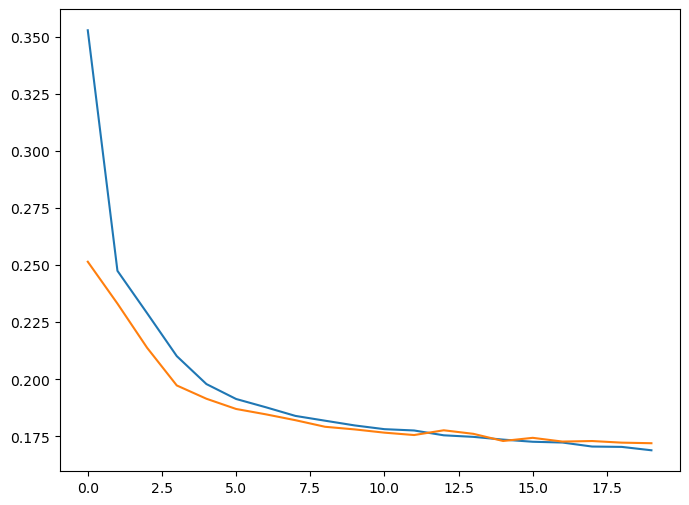

In [8]:
sample = "XYY3000_Y170_Yp170"
variables_signal = ['lund_weights','nom_sys_wgt'] + variables
data = loadData(sample,variables_signal,nMax=nevts,dEta_cut=dEta_cut,sideband=sideband,mode=mode)
mass_cut = mjj_cut(data[:,2],mres=mres)
sig, sig_wgts = data[:,3:], np.prod(data[:,:2],axis=1)
sig = (sig-bkg_mean)/bkg_std
del data
sig_train, wgt_sig_train, sig_val, wgt_sig_val, sig_test, wgt_sig_test = train_test_val_split(sig,sig_wgts)

model = train(sig_train, bkg_train, wgt_sig_train, wgt_bkg_train, sig_val, bkg_val, wgt_sig_val, wgt_bkg_val, device)
model = model.to('cpu')
torch.cuda.empty_cache()
torch.save(model,f"fully_supervised_test_Jan2025/model_{sample}.pt")

test = np.concatenate((sig_test,bkg_test),axis=0)
test_labels = np.concatenate((np.ones(sig_test.shape[0]),np.zeros(bkg_test.shape[0])),axis=0)
test_wgt = np.concatenate((wgt_sig_test,wgt_bkg_test),axis=0)
with torch.no_grad():
    test_predictions = model(torch.tensor(test)).numpy()[:,0]

fpr, tpr, _ = metrics.roc_curve(test_labels, test_predictions, sample_weight=test_wgt)
sic = tpr / np.sqrt(fpr)

results = {
    'AUC': metrics.roc_auc_score(test_labels, test_predictions, sample_weight=test_wgt),
    'Accuracy': metrics.accuracy_score(test_labels, np.round(test_predictions), sample_weight=test_wgt),
    'BCE': metrics.log_loss(test_labels, test_predictions, sample_weight=test_wgt),
    'SIC-10%': np.interp(0.1, fpr, sic),
    'SIC-2.5%': np.interp(0.025, fpr, sic),
    'SIC-1%': np.interp(0.01, fpr, sic),
}
print(json.dumps(results,indent=4))

file_name = signal_map[sample]
if os.path.exists(f"fully_supervised_test_Jan2025/QUAK_{mres}.json"):
    with open(f"fully_supervised_test_Jan2025/QUAK_{mres}.json","r") as fin:
        all_results = json.load(fin)
else:
    all_results = {}
all_results[file_name] = results
with open(f"fully_supervised_test_Jan2025/QUAK_{mres}.json","w") as fout:
    json.dump(all_results,fout,indent=4)

del model

### Wprime B400

  5%|▌         | 1/20 [00:02<00:51,  2.73s/it]

Epoch [1/20], Loss: 0.3428, Val: 0.2374


 10%|█         | 2/20 [00:05<00:48,  2.70s/it]

Epoch [2/20], Loss: 0.2210, Val: 0.2162


 15%|█▌        | 3/20 [00:08<00:45,  2.68s/it]

...

Epoch [19/20], Loss: 0.1781, Val: 0.1914


100%|██████████| 20/20 [00:53<00:00,  2.68s/it]

Epoch [20/20], Loss: 0.1778, Val: 0.1896


{
    "AUC": 0.9712958012257111,
    "Accuracy": 0.9245494479445959,
    "BCE": 0.1850128789605445,
    "SIC-10%": 2.9184304817247946,
    "SIC-2.5%": 4.680709123462214,
    "SIC-1%": 5.735070415706029
}


/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:22: RuntimeWarning: divide by zero encountered in true_divide
/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:22: RuntimeWarning: invalid value encountered in true_divide


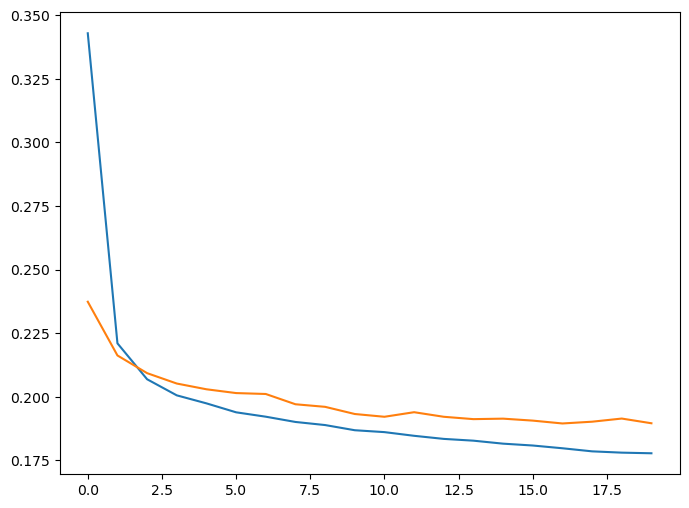

In [9]:
sample = "Wp3000_B400_T170"
variables_signal = ['lund_weights','nom_sys_wgt'] + variables
data = loadData(sample,variables_signal,nMax=nevts,dEta_cut=dEta_cut,sideband=sideband,mode=mode)
mass_cut = mjj_cut(data[:,2],mres=mres)
sig, sig_wgts = data[:,3:], np.prod(data[:,:2],axis=1)
sig = (sig-bkg_mean)/bkg_std
del data
sig_train, wgt_sig_train, sig_val, wgt_sig_val, sig_test, wgt_sig_test = train_test_val_split(sig,sig_wgts)

model = train(sig_train, bkg_train, wgt_sig_train, wgt_bkg_train, sig_val, bkg_val, wgt_sig_val, wgt_bkg_val, device)
model = model.to('cpu')
torch.cuda.empty_cache()
torch.save(model,f"fully_supervised_test_Jan2025/model_{sample}.pt")

test = np.concatenate((sig_test,bkg_test),axis=0)
test_labels = np.concatenate((np.ones(sig_test.shape[0]),np.zeros(bkg_test.shape[0])),axis=0)
test_wgt = np.concatenate((wgt_sig_test,wgt_bkg_test),axis=0)
with torch.no_grad():
    test_predictions = model(torch.tensor(test)).numpy()[:,0]

fpr, tpr, _ = metrics.roc_curve(test_labels, test_predictions, sample_weight=test_wgt)
sic = tpr / np.sqrt(fpr)

results = {
    'AUC': metrics.roc_auc_score(test_labels, test_predictions, sample_weight=test_wgt),
    'Accuracy': metrics.accuracy_score(test_labels, np.round(test_predictions), sample_weight=test_wgt),
    'BCE': metrics.log_loss(test_labels, test_predictions, sample_weight=test_wgt),
    'SIC-10%': np.interp(0.1, fpr, sic),
    'SIC-2.5%': np.interp(0.025, fpr, sic),
    'SIC-1%': np.interp(0.01, fpr, sic),
}
print(json.dumps(results,indent=4))

file_name = signal_map[sample]
if os.path.exists(f"fully_supervised_test_Jan2025/QUAK_{mres}.json"):
    with open(f"fully_supervised_test_Jan2025/QUAK_{mres}.json","r") as fin:
        all_results = json.load(fin)
else:
    all_results = {}
all_results[file_name] = results
with open(f"fully_supervised_test_Jan2025/QUAK_{mres}.json","w") as fout:
    json.dump(all_results,fout,indent=4)

del model

## Wkk R400

  5%|▌         | 1/20 [00:02<00:49,  2.59s/it]

Epoch [1/20], Loss: 0.3537, Val: 0.2533


 10%|█         | 2/20 [00:05<00:46,  2.56s/it]

Epoch [2/20], Loss: 0.2300, Val: 0.2320


 15%|█▌        | 3/20 [00:07<00:43,  2.57s/it]

...

Epoch [19/20], Loss: 0.1569, Val: 0.1673


100%|██████████| 20/20 [00:51<00:00,  2.56s/it]

Epoch [20/20], Loss: 0.1551, Val: 0.1683


{
    "AUC": 0.9726236799943677,
    "Accuracy": 0.9418943742048254,
    "BCE": 0.15636473172272344,
    "SIC-10%": 2.92028094327463,
    "SIC-2.5%": 5.1779657821217935,
    "SIC-1%": 7.26095669803735
}


/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:22: RuntimeWarning: divide by zero encountered in true_divide
/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:22: RuntimeWarning: invalid value encountered in true_divide


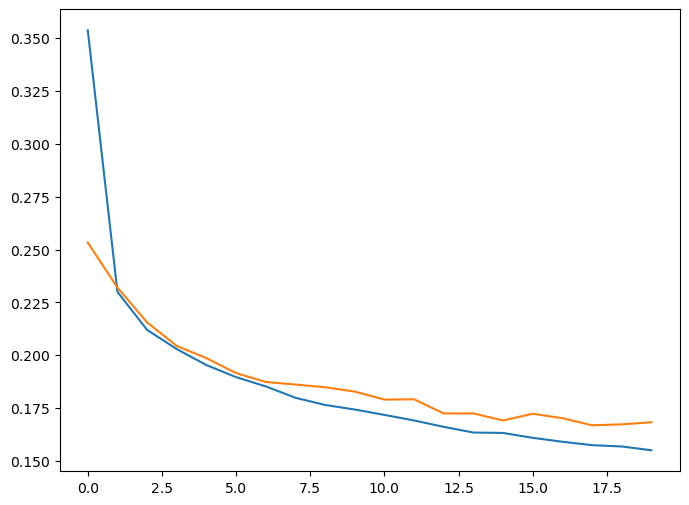

In [10]:
sample = "Wkk3000_R400"
variables_signal = ['lund_weights','nom_sys_wgt'] + variables
data = loadData(sample,variables_signal,nMax=nevts,dEta_cut=dEta_cut,sideband=sideband,mode=mode)
mass_cut = mjj_cut(data[:,2],mres=mres)
sig, sig_wgts = data[:,3:], np.prod(data[:,:2],axis=1)
sig = (sig-bkg_mean)/bkg_std
del data
sig_train, wgt_sig_train, sig_val, wgt_sig_val, sig_test, wgt_sig_test = train_test_val_split(sig,sig_wgts)

model = train(sig_train, bkg_train, wgt_sig_train, wgt_bkg_train, sig_val, bkg_val, wgt_sig_val, wgt_bkg_val, device)
model = model.to('cpu')
torch.cuda.empty_cache()
torch.save(model,f"fully_supervised_test_Jan2025/model_{sample}.pt")

test = np.concatenate((sig_test,bkg_test),axis=0)
test_labels = np.concatenate((np.ones(sig_test.shape[0]),np.zeros(bkg_test.shape[0])),axis=0)
test_wgt = np.concatenate((wgt_sig_test,wgt_bkg_test),axis=0)
with torch.no_grad():
    test_predictions = model(torch.tensor(test)).numpy()[:,0]

fpr, tpr, _ = metrics.roc_curve(test_labels, test_predictions, sample_weight=test_wgt)
sic = tpr / np.sqrt(fpr)

results = {
    'AUC': metrics.roc_auc_score(test_labels, test_predictions, sample_weight=test_wgt),
    'Accuracy': metrics.accuracy_score(test_labels, np.round(test_predictions), sample_weight=test_wgt),
    'BCE': metrics.log_loss(test_labels, test_predictions, sample_weight=test_wgt),
    'SIC-10%': np.interp(0.1, fpr, sic),
    'SIC-2.5%': np.interp(0.025, fpr, sic),
    'SIC-1%': np.interp(0.01, fpr, sic),
}
print(json.dumps(results,indent=4))

file_name = signal_map[sample]
if os.path.exists(f"fully_supervised_test_Jan2025/QUAK_{mres}.json"):
    with open(f"fully_supervised_test_Jan2025/QUAK_{mres}.json","r") as fin:
        all_results = json.load(fin)
else:
    all_results = {}
all_results[file_name] = results
with open(f"fully_supervised_test_Jan2025/QUAK_{mres}.json","w") as fout:
    json.dump(all_results,fout,indent=4)

del model

## YHH H400

  5%|▌         | 1/20 [00:03<01:15,  4.00s/it]

Epoch [1/20], Loss: 0.1731, Val: 0.0895


 10%|█         | 2/20 [00:08<01:12,  4.02s/it]

Epoch [2/20], Loss: 0.0779, Val: 0.0703


 15%|█▌        | 3/20 [00:12<01:08,  4.01s/it]

...

Epoch [19/20], Loss: 0.0543, Val: 0.0596


100%|██████████| 20/20 [01:20<00:00,  4.02s/it]

Epoch [20/20], Loss: 0.0541, Val: 0.0613


{
    "AUC": 0.9974164835239344,
    "Accuracy": 0.9781558669791819,
    "BCE": 0.061299728706873946,
    "SIC-10%": 3.1491121924655348,
    "SIC-2.5%": 6.202609411178843,
    "SIC-1%": 9.588867212099208
}


/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:22: RuntimeWarning: divide by zero encountered in true_divide
/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:22: RuntimeWarning: invalid value encountered in true_divide


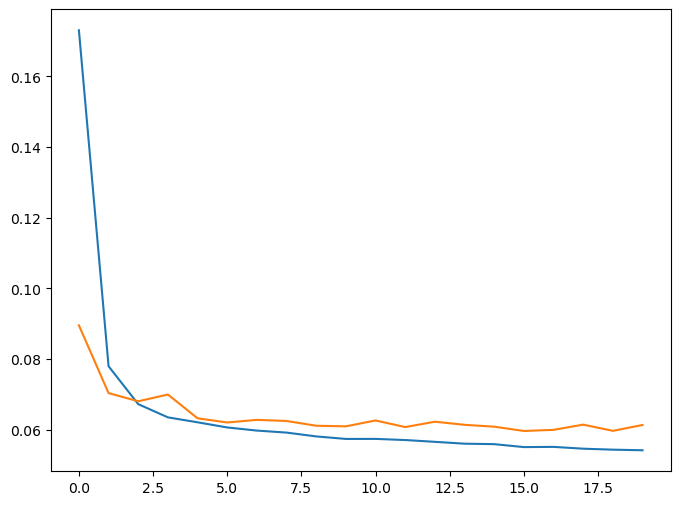

In [11]:
sample = "YHH3000_H400"
variables_signal = ['lund_weights','nom_sys_wgt'] + variables
data = loadData(sample,variables_signal,nMax=nevts,dEta_cut=dEta_cut,sideband=sideband,mode=mode)
mass_cut = mjj_cut(data[:,2],mres=mres)
sig, sig_wgts = data[:,3:], np.prod(data[:,:2],axis=1)
sig = (sig-bkg_mean)/bkg_std
del data
sig_train, wgt_sig_train, sig_val, wgt_sig_val, sig_test, wgt_sig_test = train_test_val_split(sig,sig_wgts)

model = train(sig_train, bkg_train, wgt_sig_train, wgt_bkg_train, sig_val, bkg_val, wgt_sig_val, wgt_bkg_val, device)
model = model.to('cpu')
torch.cuda.empty_cache()
torch.save(model,f"fully_supervised_test_Jan2025/model_{sample}.pt")

test = np.concatenate((sig_test,bkg_test),axis=0)
test_labels = np.concatenate((np.ones(sig_test.shape[0]),np.zeros(bkg_test.shape[0])),axis=0)
test_wgt = np.concatenate((wgt_sig_test,wgt_bkg_test),axis=0)
with torch.no_grad():
    test_predictions = model(torch.tensor(test)).numpy()[:,0]

fpr, tpr, _ = metrics.roc_curve(test_labels, test_predictions, sample_weight=test_wgt)
sic = tpr / np.sqrt(fpr)

results = {
    'AUC': metrics.roc_auc_score(test_labels, test_predictions, sample_weight=test_wgt),
    'Accuracy': metrics.accuracy_score(test_labels, np.round(test_predictions), sample_weight=test_wgt),
    'BCE': metrics.log_loss(test_labels, test_predictions, sample_weight=test_wgt),
    'SIC-10%': np.interp(0.1, fpr, sic),
    'SIC-2.5%': np.interp(0.025, fpr, sic),
    'SIC-1%': np.interp(0.01, fpr, sic),
}
print(json.dumps(results,indent=4))

file_name = signal_map[sample]
if os.path.exists(f"fully_supervised_test_Jan2025/QUAK_{mres}.json"):
    with open(f"fully_supervised_test_Jan2025/QUAK_{mres}.json","r") as fin:
        all_results = json.load(fin)
else:
    all_results = {}
all_results[file_name] = results
with open(f"fully_supervised_test_Jan2025/QUAK_{mres}.json","w") as fout:
    json.dump(all_results,fout,indent=4)

del model

# 5 TeV trainings

In [12]:
mres = 5000

In [13]:
# load bkg MC
vars_bkg = ['']
data = loadData("DATA",variables,nMax=nevts,dEta_cut=dEta_cut,sideband=sideband,mode=mode)
mass_cut = mjj_cut(data[:,0],mres=mres)
bkg = data[mass_cut][:,1:] # remove mjj entry
bkg_mean = np.mean(bkg,axis=0)
bkg_std = np.std(bkg,axis=0)
bkg = (bkg-bkg_mean)/bkg_std
del data
bkg_train, wgt_bkg_train, bkg_val, wgt_bkg_val, bkg_test, wgt_bkg_test = train_test_val_split(bkg,np.ones(len(bkg)))

100%|██████████| 40/40 [03:02<00:00,  4.57s/it]


### XYY (170,170)

  5%|▌         | 1/20 [00:01<00:19,  1.01s/it]

Epoch [1/20], Loss: 0.3155, Val: 0.1424


 10%|█         | 2/20 [00:02<00:18,  1.01s/it]

Epoch [2/20], Loss: 0.1246, Val: 0.1138


 15%|█▌        | 3/20 [00:03<00:17,  1.03s/it]

...

Epoch [19/20], Loss: 0.0677, Val: 0.0779


100%|██████████| 20/20 [00:20<00:00,  1.02s/it]

Epoch [20/20], Loss: 0.0668, Val: 0.0779


{
    "AUC": 0.9671655594055356,
    "Accuracy": 0.973144220052086,
    "BCE": 0.07424154134738586,
    "SIC-10%": 2.886207613801454,
    "SIC-2.5%": 4.8190561880381635,
    "SIC-1%": 6.755898566222776
}


/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:22: RuntimeWarning: divide by zero encountered in true_divide
/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:22: RuntimeWarning: invalid value encountered in true_divide


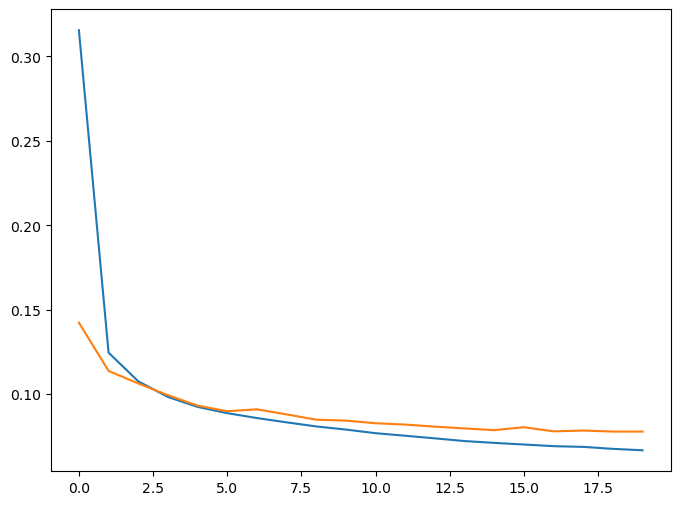

In [14]:
sample = "XYY5000_Y170_Yp170"
variables_signal = ['lund_weights','nom_sys_wgt'] + variables
data = loadData(sample,variables_signal,nMax=nevts,dEta_cut=dEta_cut,sideband=sideband,mode=mode)
mass_cut = mjj_cut(data[:,2],mres=mres)
sig, sig_wgts = data[:,3:], np.prod(data[:,:2],axis=1)
sig = (sig-bkg_mean)/bkg_std
del data
sig_train, wgt_sig_train, sig_val, wgt_sig_val, sig_test, wgt_sig_test = train_test_val_split(sig,sig_wgts)

model = train(sig_train, bkg_train, wgt_sig_train, wgt_bkg_train, sig_val, bkg_val, wgt_sig_val, wgt_bkg_val, device)
model = model.to('cpu')
torch.cuda.empty_cache()
torch.save(model,f"fully_supervised_test_Jan2025/model_{sample}.pt")

test = np.concatenate((sig_test,bkg_test),axis=0)
test_labels = np.concatenate((np.ones(sig_test.shape[0]),np.zeros(bkg_test.shape[0])),axis=0)
test_wgt = np.concatenate((wgt_sig_test,wgt_bkg_test),axis=0)
with torch.no_grad():
    test_predictions = model(torch.tensor(test)).numpy()[:,0]

fpr, tpr, _ = metrics.roc_curve(test_labels, test_predictions, sample_weight=test_wgt)
sic = tpr / np.sqrt(fpr)

results = {
    'AUC': metrics.roc_auc_score(test_labels, test_predictions, sample_weight=test_wgt),
    'Accuracy': metrics.accuracy_score(test_labels, np.round(test_predictions), sample_weight=test_wgt),
    'BCE': metrics.log_loss(test_labels, test_predictions, sample_weight=test_wgt),
    'SIC-10%': np.interp(0.1, fpr, sic),
    'SIC-2.5%': np.interp(0.025, fpr, sic),
    'SIC-1%': np.interp(0.01, fpr, sic),
}
print(json.dumps(results,indent=4))

file_name = signal_map[sample]
if os.path.exists(f"fully_supervised_test_Jan2025/QUAK_{mres}.json"):
    with open(f"fully_supervised_test_Jan2025/QUAK_{mres}.json","r") as fin:
        all_results = json.load(fin)
else:
    all_results = {}
all_results[file_name] = results
with open(f"fully_supervised_test_Jan2025/QUAK_{mres}.json","w") as fout:
    json.dump(all_results,fout,indent=4)

del model

### Wprime B400

  5%|▌         | 1/20 [00:00<00:12,  1.56it/s]

Epoch [1/20], Loss: 0.4342, Val: 0.1798


 10%|█         | 2/20 [00:01<00:11,  1.56it/s]

Epoch [2/20], Loss: 0.1543, Val: 0.1430


 15%|█▌        | 3/20 [00:01<00:10,  1.56it/s]

...

Epoch [19/20], Loss: 0.0836, Val: 0.0873


100%|██████████| 20/20 [00:12<00:00,  1.58it/s]

Epoch [20/20], Loss: 0.0832, Val: 0.0866


{
    "AUC": 0.962466665423292,
    "Accuracy": 0.9688980077428746,
    "BCE": 0.09449487750239945,
    "SIC-10%": 2.863679091041292,
    "SIC-2.5%": 4.0690673075580355,
    "SIC-1%": 4.709884359640787
}


/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:22: RuntimeWarning: divide by zero encountered in true_divide
/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:22: RuntimeWarning: invalid value encountered in true_divide


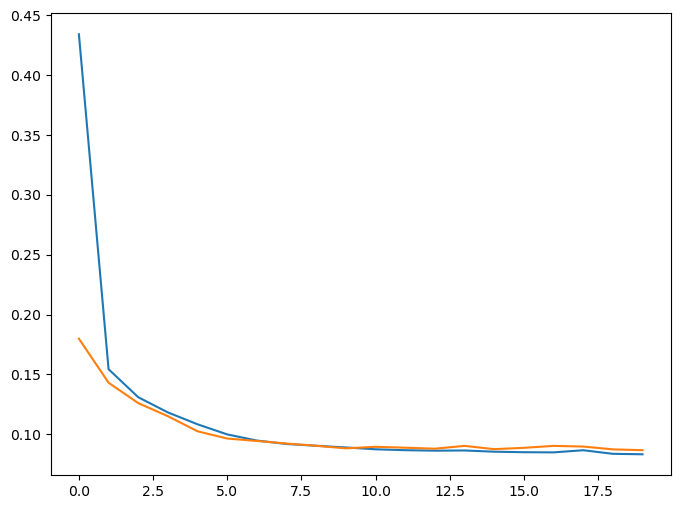

In [15]:
sample = "Wp5000_B400_T170"
variables_signal = ['lund_weights','nom_sys_wgt'] + variables
data = loadData(sample,variables_signal,nMax=nevts,dEta_cut=dEta_cut,sideband=sideband,mode=mode)
mass_cut = mjj_cut(data[:,2],mres=mres)
sig, sig_wgts = data[:,3:], np.prod(data[:,:2],axis=1)
sig = (sig-bkg_mean)/bkg_std
del data
sig_train, wgt_sig_train, sig_val, wgt_sig_val, sig_test, wgt_sig_test = train_test_val_split(sig,sig_wgts)

model = train(sig_train, bkg_train, wgt_sig_train, wgt_bkg_train, sig_val, bkg_val, wgt_sig_val, wgt_bkg_val, device)
model = model.to('cpu')
torch.cuda.empty_cache()
torch.save(model,f"fully_supervised_test_Jan2025/model_{sample}.pt")

test = np.concatenate((sig_test,bkg_test),axis=0)
test_labels = np.concatenate((np.ones(sig_test.shape[0]),np.zeros(bkg_test.shape[0])),axis=0)
test_wgt = np.concatenate((wgt_sig_test,wgt_bkg_test),axis=0)
with torch.no_grad():
    test_predictions = model(torch.tensor(test)).numpy()[:,0]

fpr, tpr, _ = metrics.roc_curve(test_labels, test_predictions, sample_weight=test_wgt)
sic = tpr / np.sqrt(fpr)

results = {
    'AUC': metrics.roc_auc_score(test_labels, test_predictions, sample_weight=test_wgt),
    'Accuracy': metrics.accuracy_score(test_labels, np.round(test_predictions), sample_weight=test_wgt),
    'BCE': metrics.log_loss(test_labels, test_predictions, sample_weight=test_wgt),
    'SIC-10%': np.interp(0.1, fpr, sic),
    'SIC-2.5%': np.interp(0.025, fpr, sic),
    'SIC-1%': np.interp(0.01, fpr, sic),
}
print(json.dumps(results,indent=4))

file_name = signal_map[sample]
if os.path.exists(f"fully_supervised_test_Jan2025/QUAK_{mres}.json"):
    with open(f"fully_supervised_test_Jan2025/QUAK_{mres}.json","r") as fin:
        all_results = json.load(fin)
else:
    all_results = {}
all_results[file_name] = results
with open(f"fully_supervised_test_Jan2025/QUAK_{mres}.json","w") as fout:
    json.dump(all_results,fout,indent=4)

del model

## Wkk R400

  5%|▌         | 1/20 [00:00<00:11,  1.65it/s]

Epoch [1/20], Loss: 0.4579, Val: 0.2110


 10%|█         | 2/20 [00:01<00:10,  1.64it/s]

Epoch [2/20], Loss: 0.1999, Val: 0.1865


 15%|█▌        | 3/20 [00:01<00:10,  1.70it/s]

...

Epoch [19/20], Loss: 0.1167, Val: 0.1218


100%|██████████| 20/20 [00:12<00:00,  1.66it/s]

Epoch [20/20], Loss: 0.1138, Val: 0.1255


{
    "AUC": 0.9530788695196544,
    "Accuracy": 0.9503300499512148,
    "BCE": 0.1231631937297813,
    "SIC-10%": 2.7418069757639434,
    "SIC-2.5%": 4.673300351961681,
    "SIC-1%": 5.574974773256043
}


/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:22: RuntimeWarning: divide by zero encountered in true_divide
/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:22: RuntimeWarning: invalid value encountered in true_divide


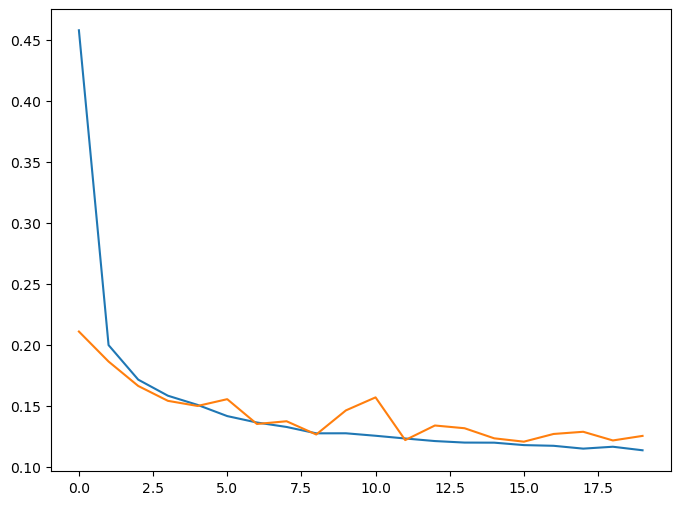

In [16]:
sample = "Wkk5000_R400"
variables_signal = ['lund_weights','nom_sys_wgt'] + variables
data = loadData(sample,variables_signal,nMax=nevts,dEta_cut=dEta_cut,sideband=sideband,mode=mode)
mass_cut = mjj_cut(data[:,2],mres=mres)
sig, sig_wgts = data[:,3:], np.prod(data[:,:2],axis=1)
sig = (sig-bkg_mean)/bkg_std
del data
sig_train, wgt_sig_train, sig_val, wgt_sig_val, sig_test, wgt_sig_test = train_test_val_split(sig,sig_wgts)

model = train(sig_train, bkg_train, wgt_sig_train, wgt_bkg_train, sig_val, bkg_val, wgt_sig_val, wgt_bkg_val, device)
model = model.to('cpu')
torch.cuda.empty_cache()
torch.save(model,f"fully_supervised_test_Jan2025/model_{sample}.pt")

test = np.concatenate((sig_test,bkg_test),axis=0)
test_labels = np.concatenate((np.ones(sig_test.shape[0]),np.zeros(bkg_test.shape[0])),axis=0)
test_wgt = np.concatenate((wgt_sig_test,wgt_bkg_test),axis=0)
with torch.no_grad():
    test_predictions = model(torch.tensor(test)).numpy()[:,0]

fpr, tpr, _ = metrics.roc_curve(test_labels, test_predictions, sample_weight=test_wgt)
sic = tpr / np.sqrt(fpr)

results = {
    'AUC': metrics.roc_auc_score(test_labels, test_predictions, sample_weight=test_wgt),
    'Accuracy': metrics.accuracy_score(test_labels, np.round(test_predictions), sample_weight=test_wgt),
    'BCE': metrics.log_loss(test_labels, test_predictions, sample_weight=test_wgt),
    'SIC-10%': np.interp(0.1, fpr, sic),
    'SIC-2.5%': np.interp(0.025, fpr, sic),
    'SIC-1%': np.interp(0.01, fpr, sic),
}
print(json.dumps(results,indent=4))

file_name = signal_map[sample]
if os.path.exists(f"fully_supervised_test_Jan2025/QUAK_{mres}.json"):
    with open(f"fully_supervised_test_Jan2025/QUAK_{mres}.json","r") as fin:
        all_results = json.load(fin)
else:
    all_results = {}
all_results[file_name] = results
with open(f"fully_supervised_test_Jan2025/QUAK_{mres}.json","w") as fout:
    json.dump(all_results,fout,indent=4)

del model

## YHH H400

  5%|▌         | 1/20 [00:02<00:40,  2.15s/it]

Epoch [1/20], Loss: 0.1329, Val: 0.0273


 10%|█         | 2/20 [00:04<00:38,  2.15s/it]

Epoch [2/20], Loss: 0.0234, Val: 0.0200


 15%|█▌        | 3/20 [00:06<00:36,  2.15s/it]

...

Epoch [19/20], Loss: 0.0110, Val: 0.0115


100%|██████████| 20/20 [00:42<00:00,  2.15s/it]

Epoch [20/20], Loss: 0.0106, Val: 0.0116


{
    "AUC": 0.9975043402410648,
    "Accuracy": 0.9958125660961746,
    "BCE": 0.012998383606732937,
    "SIC-10%": 3.153849136231602,
    "SIC-2.5%": 6.205269081225083,
    "SIC-1%": 9.60068605022735
}


/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:22: RuntimeWarning: divide by zero encountered in true_divide
/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:22: RuntimeWarning: invalid value encountered in true_divide


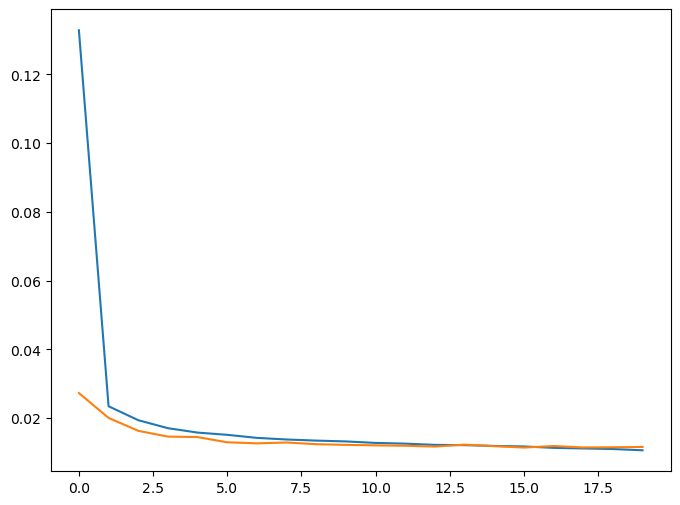

In [17]:
sample = "YHH5000_H400"
variables_signal = ['lund_weights','nom_sys_wgt'] + variables
data = loadData(sample,variables_signal,nMax=nevts,dEta_cut=dEta_cut,sideband=sideband,mode=mode)
mass_cut = mjj_cut(data[:,2],mres=mres)
sig, sig_wgts = data[:,3:], np.prod(data[:,:2],axis=1)
sig = (sig-bkg_mean)/bkg_std
del data
sig_train, wgt_sig_train, sig_val, wgt_sig_val, sig_test, wgt_sig_test = train_test_val_split(sig,sig_wgts)

model = train(sig_train, bkg_train, wgt_sig_train, wgt_bkg_train, sig_val, bkg_val, wgt_sig_val, wgt_bkg_val, device)
model = model.to('cpu')
torch.cuda.empty_cache()
torch.save(model,f"fully_supervised_test_Jan2025/model_{sample}.pt")

test = np.concatenate((sig_test,bkg_test),axis=0)
test_labels = np.concatenate((np.ones(sig_test.shape[0]),np.zeros(bkg_test.shape[0])),axis=0)
test_wgt = np.concatenate((wgt_sig_test,wgt_bkg_test),axis=0)
with torch.no_grad():
    test_predictions = model(torch.tensor(test)).numpy()[:,0]

fpr, tpr, _ = metrics.roc_curve(test_labels, test_predictions, sample_weight=test_wgt)
sic = tpr / np.sqrt(fpr)

results = {
    'AUC': metrics.roc_auc_score(test_labels, test_predictions, sample_weight=test_wgt),
    'Accuracy': metrics.accuracy_score(test_labels, np.round(test_predictions), sample_weight=test_wgt),
    'BCE': metrics.log_loss(test_labels, test_predictions, sample_weight=test_wgt),
    'SIC-10%': np.interp(0.1, fpr, sic),
    'SIC-2.5%': np.interp(0.025, fpr, sic),
    'SIC-1%': np.interp(0.01, fpr, sic),
}
print(json.dumps(results,indent=4))

file_name = signal_map[sample]
if os.path.exists(f"fully_supervised_test_Jan2025/QUAK_{mres}.json"):
    with open(f"fully_supervised_test_Jan2025/QUAK_{mres}.json","r") as fin:
        all_results = json.load(fin)
else:
    all_results = {}
all_results[file_name] = results
with open(f"fully_supervised_test_Jan2025/QUAK_{mres}.json","w") as fout:
    json.dump(all_results,fout,indent=4)

del model